In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv("heart_disease_uci.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(920, 16)
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [2]:
print(df.isnull().sum())
print(df.dtypes)
for c in ["sex","cp","fbs","restecg","exang","slope","thal"]:
    print(c, df[c].unique())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object
sex ['Male' 'Female']
cp ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
fbs [True False nan]
restecg ['lv hypertrophy' 'normal' 'st-t abnormality' nan]
exang [False True nan]
slope ['downsloping' 'flat' 'upsloping' nan]
thal ['fixed defect' 'normal' 'reversable defect' nan]


In [3]:
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num", "id", "dataset"])

# Cholesterol and blood pressure of 0 are impossible; they mean "not recorded"
df.loc[df["chol"] == 0, "chol"] = np.nan
df.loc[df["trestbps"] == 0, "trestbps"] = np.nan

print(df["target"].value_counts())

target
1    509
0    411
Name: count, dtype: int64


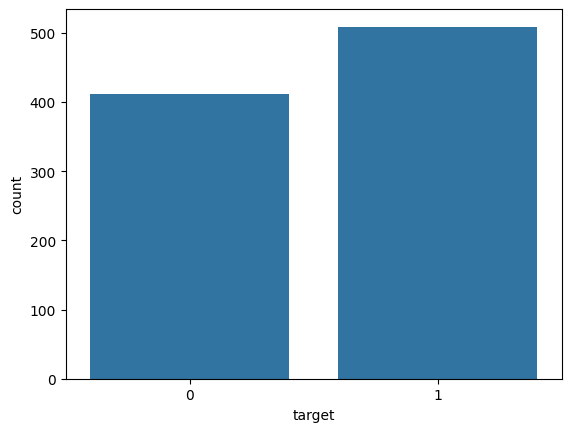

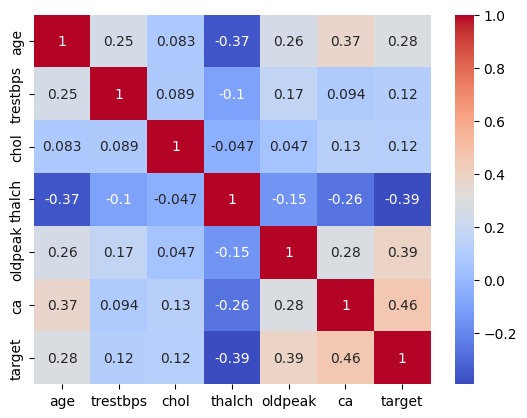

In [4]:
sns.countplot(x="target", data=df); plt.show()
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm"); plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

# make every categorical value a string (booleans + NaN otherwise break the encoder)
for c in cat_cols:
    df[c] = df[c].map(lambda x: str(x) if pd.notna(x) else np.nan)

X = df[num_cols + cat_cols]
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("scale", StandardScaler())])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                     ("ohe", OneHotEncoder(handle_unknown="ignore"))])

pre = ColumnTransformer([("num", num_pipe, num_cols),
                         ("cat", cat_pipe, cat_cols)])

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                             eval_metric="logloss", random_state=42),
}

pipes = {}
for name, model in models.items():
    pipes[name] = Pipeline([("pre", pre), ("model", model)]).fit(X_train, y_train)

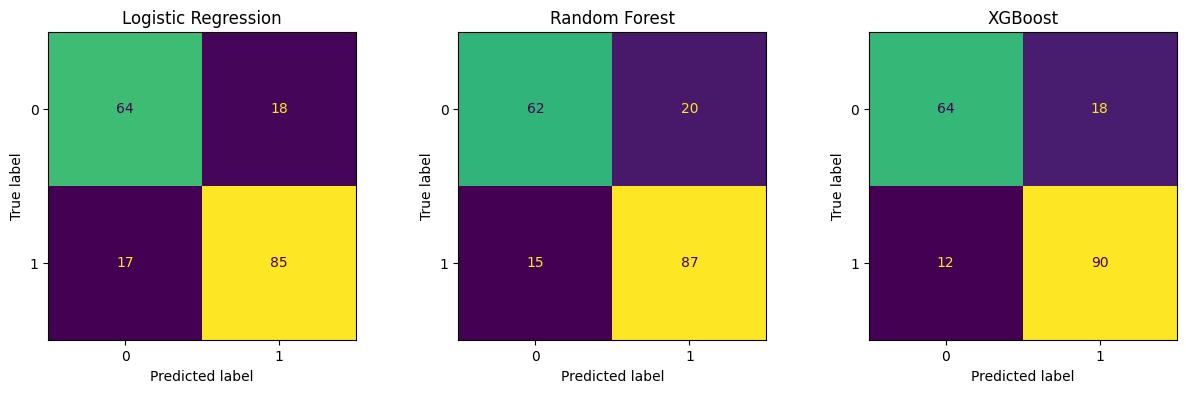

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.810,0.825,0.833,0.829,0.890
1,Random Forest,0.810,0.813,0.853,0.833,0.906
2,XGBoost,0.837,0.833,0.882,0.857,0.902


In [7]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, pipes.items()):
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred),
                 "Recall": recall_score(y_test, pred),
                 "F1": f1_score(y_test, pred),
                 "ROC-AUC": roc_auc_score(y_test, proba)})
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred)).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.show()
results = pd.DataFrame(rows).round(3)
results

In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(5, shuffle=True, random_state=42)
for name, pipe in pipes.items():
    s = cross_val_score(pipe, X, y, cv=cv, scoring="recall")
    print(f"{name}: recall {s.mean():.3f} ± {s.std():.3f}")

Logistic Regression: recall 0.811 ± 0.057
Random Forest: recall 0.859 ± 0.025
XGBoost: recall 0.845 ± 0.035


In [9]:
from sklearn.model_selection import cross_val_predict
best_name = "Random Forest"   # change to whichever model won on recall + ROC-AUC
proba_cv = cross_val_predict(pipes[best_name], X_train, y_train, cv=cv, method="predict_proba")[:, 1]

for t in [0.5, 0.45, 0.4, 0.35, 0.3]:
    p = (proba_cv >= t).astype(int)
    print(t, "recall", round(recall_score(y_train, p), 3), "precision", round(precision_score(y_train, p), 3))

0.5 recall 0.86 precision 0.814
0.45 recall 0.885 precision 0.802
0.4 recall 0.907 precision 0.783
0.35 recall 0.921 precision 0.756
0.3 recall 0.951 precision 0.733


In [10]:
THRESHOLD = 0.4   # your chosen value
final_pred = (pipes[best_name].predict_proba(X_test)[:, 1] >= THRESHOLD).astype(int)
print(confusion_matrix(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred), "Precision:", precision_score(y_test, final_pred))

[[56 26]
 [ 6 96]]
Recall: 0.9411764705882353 Precision: 0.7868852459016393


In [11]:
import joblib, sklearn
joblib.dump({"pipe": pipes[best_name], "threshold": THRESHOLD}, "model.joblib")
print(sklearn.__version__)   # write this down
from google.colab import files
files.download("model.joblib")

1.6.1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import sklearn, xgboost
print(sklearn.__version__, xgboost.__version__)

1.6.1 3.4.1
